# EDA — Dataset de Clasificación: Predicción de Diabetes
**Dataset:** Diabetes Health Indicators (BRFSS 2015)  
**Fuente:** https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset  
**Variable objetivo:** `Diabetes_binary` (0 = sin diabetes, 1 = diabético/prediabético)

---
## Contenido
1. Carga de datos y vista general
2. Identificación de tipos de variables
3. Análisis descriptivo (media, mediana, std, distribuciones)
4. Identificación de valores faltantes
5. Identificación de valores atípicos
6. Análisis de correlación
7. Relaciones entre variables (boxplots)
8. Pruebas de asociación y dependencia
9. Imputación de datos faltantes
10. Conclusiones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, kruskal
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')

# Estilo general de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

# ── Rutas ────────────────────────────────────────────────────────────────────
BASE_DIR  = Path('..').resolve()
CSV_PATH  = BASE_DIR / 'data' / 'raw' / 'dataset_clasificacion' \
            / 'diabetes_binary_health_indicators_BRFSS2015.csv'
DB_PATH   = BASE_DIR / 'database' / 'diabetes_clasificacion.db'

print('Rutas configuradas.')
print(f'  CSV : {CSV_PATH}')
print(f'  DB  : {DB_PATH}')

Rutas configuradas.
  CSV : /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/data/raw/dataset_clasificacion/diabetes_binary_health_indicators_BRFSS2015.csv
  DB  : /workspaces/ml-project_analitica_datosv/ml-proyecto_analitica_datos/database/diabetes_clasificacion.db


---
## 1. Carga de datos y vista general

In [3]:
# Cargar desde CSV (fuente primaria)
df = pd.read_csv(CSV_PATH)

print(f'Dimensiones : {df.shape[0]:,} filas  x  {df.shape[1]} columnas')
print(f'Memoria     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
df.head()

Dimensiones : 253,680 filas  x  22 columnas
Memoria     : 44.6 MB



,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
# También se puede cargar desde SQLite si la BD ya fue creada
# (ejecutar database/crear_base_datos.py primero)
if DB_PATH.exists():
    conn = sqlite3.connect(DB_PATH)
    df_sql = pd.read_sql('SELECT * FROM diabetes', conn)
    conn.close()
    print(f'Cargado desde SQLite: {df_sql.shape}')
else:
    print('Base de datos SQLite no encontrada. Usando CSV directamente.')

Cargado desde SQLite: (253680, 22)


In [5]:
# Vista general de tipos de datos y valores nulos
info_df = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notnull().sum(),
    'null'       : df.isnull().sum(),
    'null_pct'   : (df.isnull().sum() / len(df) * 100).round(2),
    'unique'     : df.nunique(),
    'sample_val' : df.iloc[0]
})
print('Resumen de columnas:')
info_df

Resumen de columnas:


,dtype,non_null,null,null_pct,unique,sample_val
Diabetes_binary,float64,253680,0,0.0,2,0.0
HighBP,float64,253680,0,0.0,2,1.0
HighChol,float64,253680,0,0.0,2,1.0
CholCheck,float64,253680,0,0.0,2,1.0
BMI,float64,253680,0,0.0,84,40.0
Smoker,float64,253680,0,0.0,2,1.0
Stroke,float64,253680,0,0.0,2,0.0
HeartDiseaseorAttack,float64,253680,0,0.0,2,0.0
PhysActivity,float64,253680,0,0.0,2,0.0
Fruits,float64,253680,0,0.0,2,0.0


---
## 2. Identificación de tipos de variables

In [6]:
# Clasificación manual según el diccionario de variables
vars_continuas   = ['BMI']
vars_discretas   = ['MentHlth', 'PhysHlth']
vars_ordinales   = ['GenHlth', 'Age', 'Education', 'Income']
vars_nominales   = [
    'Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'Smoker',
    'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits',
    'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
    'DiffWalk', 'Sex'
]

print('Variables numéricas continuas :', vars_continuas)
print('Variables numéricas discretas :', vars_discretas)
print('Variables categóricas ordinales:', vars_ordinales)
print('Variables categóricas nominales:', vars_nominales)
print(f'\nTotal: {len(vars_continuas)+len(vars_discretas)+len(vars_ordinales)+len(vars_nominales)} variables')

Variables numéricas continuas : ['BMI']
Variables numéricas discretas : ['MentHlth', 'PhysHlth']
Variables categóricas ordinales: ['GenHlth', 'Age', 'Education', 'Income']
Variables categóricas nominales: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Total: 22 variables


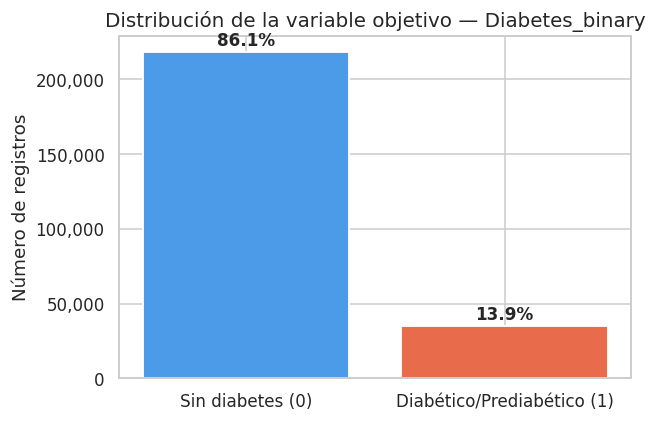


Desbalanceo: 86.1% clase 0  vs  13.9% clase 1


In [7]:
# Distribución de la variable objetivo
target_counts = df['Diabetes_binary'].value_counts()
target_pct    = df['Diabetes_binary'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Sin diabetes (0)', 'Diabético/Prediabético (1)'],
    target_counts.values,
    color=['#4C9BE8', '#E86B4C'],
    edgecolor='white', linewidth=1.2
)
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribución de la variable objetivo — Diabetes_binary', fontsize=13)
ax.set_ylabel('Número de registros')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../reports/fig_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nDesbalanceo: {target_pct.iloc[0]:.1f}% clase 0  vs  {target_pct.iloc[1]:.1f}% clase 1')

---
## 3. Análisis descriptivo

In [8]:
# Estadísticas descriptivas — variables numéricas
num_vars = vars_continuas + vars_discretas
desc = df[num_vars].describe().T
desc['median'] = df[num_vars].median()
desc['skewness'] = df[num_vars].skew()
desc = desc[['count','mean','median','std','min','25%','75%','max','skewness']]
desc.columns = ['n','media','mediana','std','min','Q1','Q3','max','asimetría']
desc.round(2)

,n,media,mediana,std,min,Q1,Q3,max,asimetría
BMI,253680.0,28.38,27.0,6.61,12.0,24.0,31.0,98.0,2.12
MentHlth,253680.0,3.18,0.0,7.41,0.0,0.0,2.0,30.0,2.72
PhysHlth,253680.0,4.24,0.0,8.72,0.0,0.0,3.0,30.0,2.21


In [9]:
# Estadísticas descriptivas — variables ordinales
desc_ord = df[vars_ordinales].describe().T
desc_ord['median'] = df[vars_ordinales].median()
desc_ord = desc_ord[['count','mean','median','std','min','max']]
desc_ord.columns = ['n','media','mediana','std','min','max']
desc_ord.round(2)

,n,media,mediana,std,min,max
GenHlth,253680.0,2.51,2.0,1.07,1.0,5.0
Age,253680.0,8.03,8.0,3.05,1.0,13.0
Education,253680.0,5.05,5.0,0.99,1.0,6.0
Income,253680.0,6.05,7.0,2.07,1.0,8.0


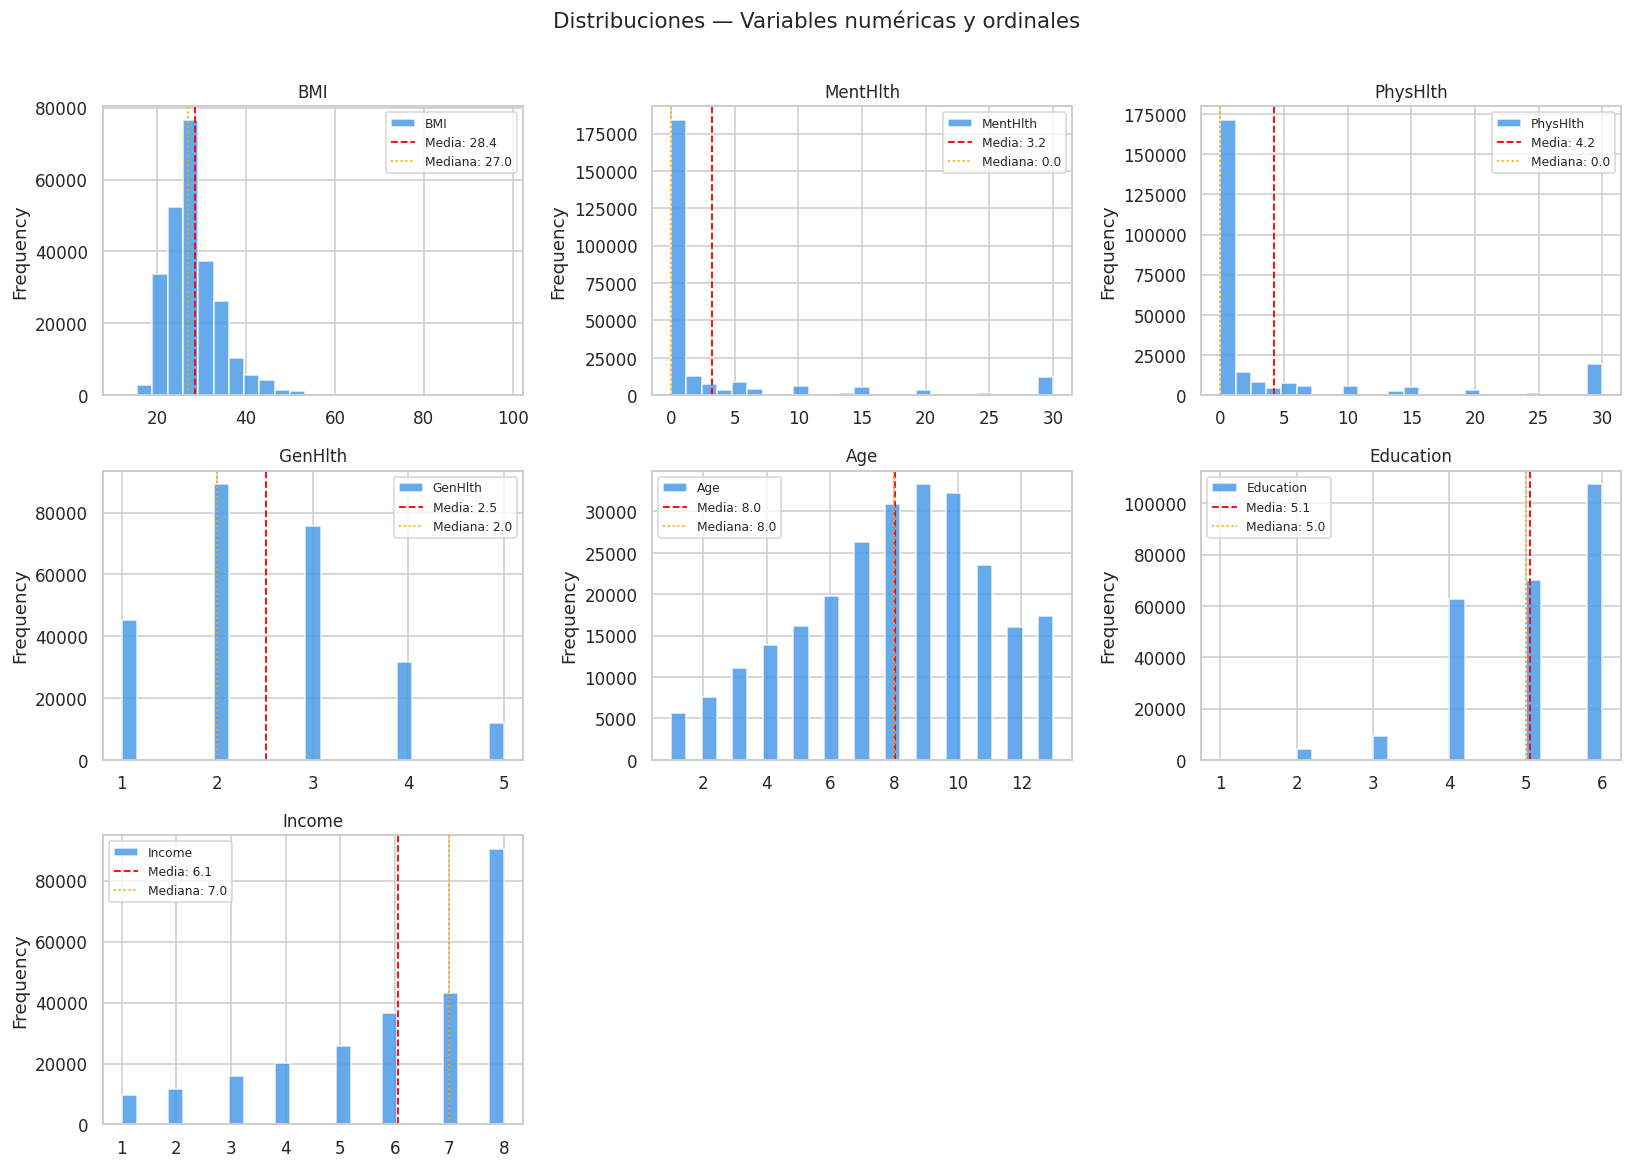

In [10]:
# Histogramas de variables numéricas y ordinales
plot_vars = vars_continuas + vars_discretas + vars_ordinales
n_cols = 3
n_rows = int(np.ceil(len(plot_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    ax = axes[i]
    df[var].plot.hist(ax=ax, bins=25, color='#4C9BE8', edgecolor='white', alpha=0.85)
    ax.axvline(df[var].mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Media: {df[var].mean():.1f}')
    ax.axvline(df[var].median(), color='orange', linestyle=':',  linewidth=1.2, label=f'Mediana: {df[var].median():.1f}')
    ax.set_title(var, fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuciones — Variables numéricas y ordinales', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_distribuciones.png', dpi=110, bbox_inches='tight')
plt.show()

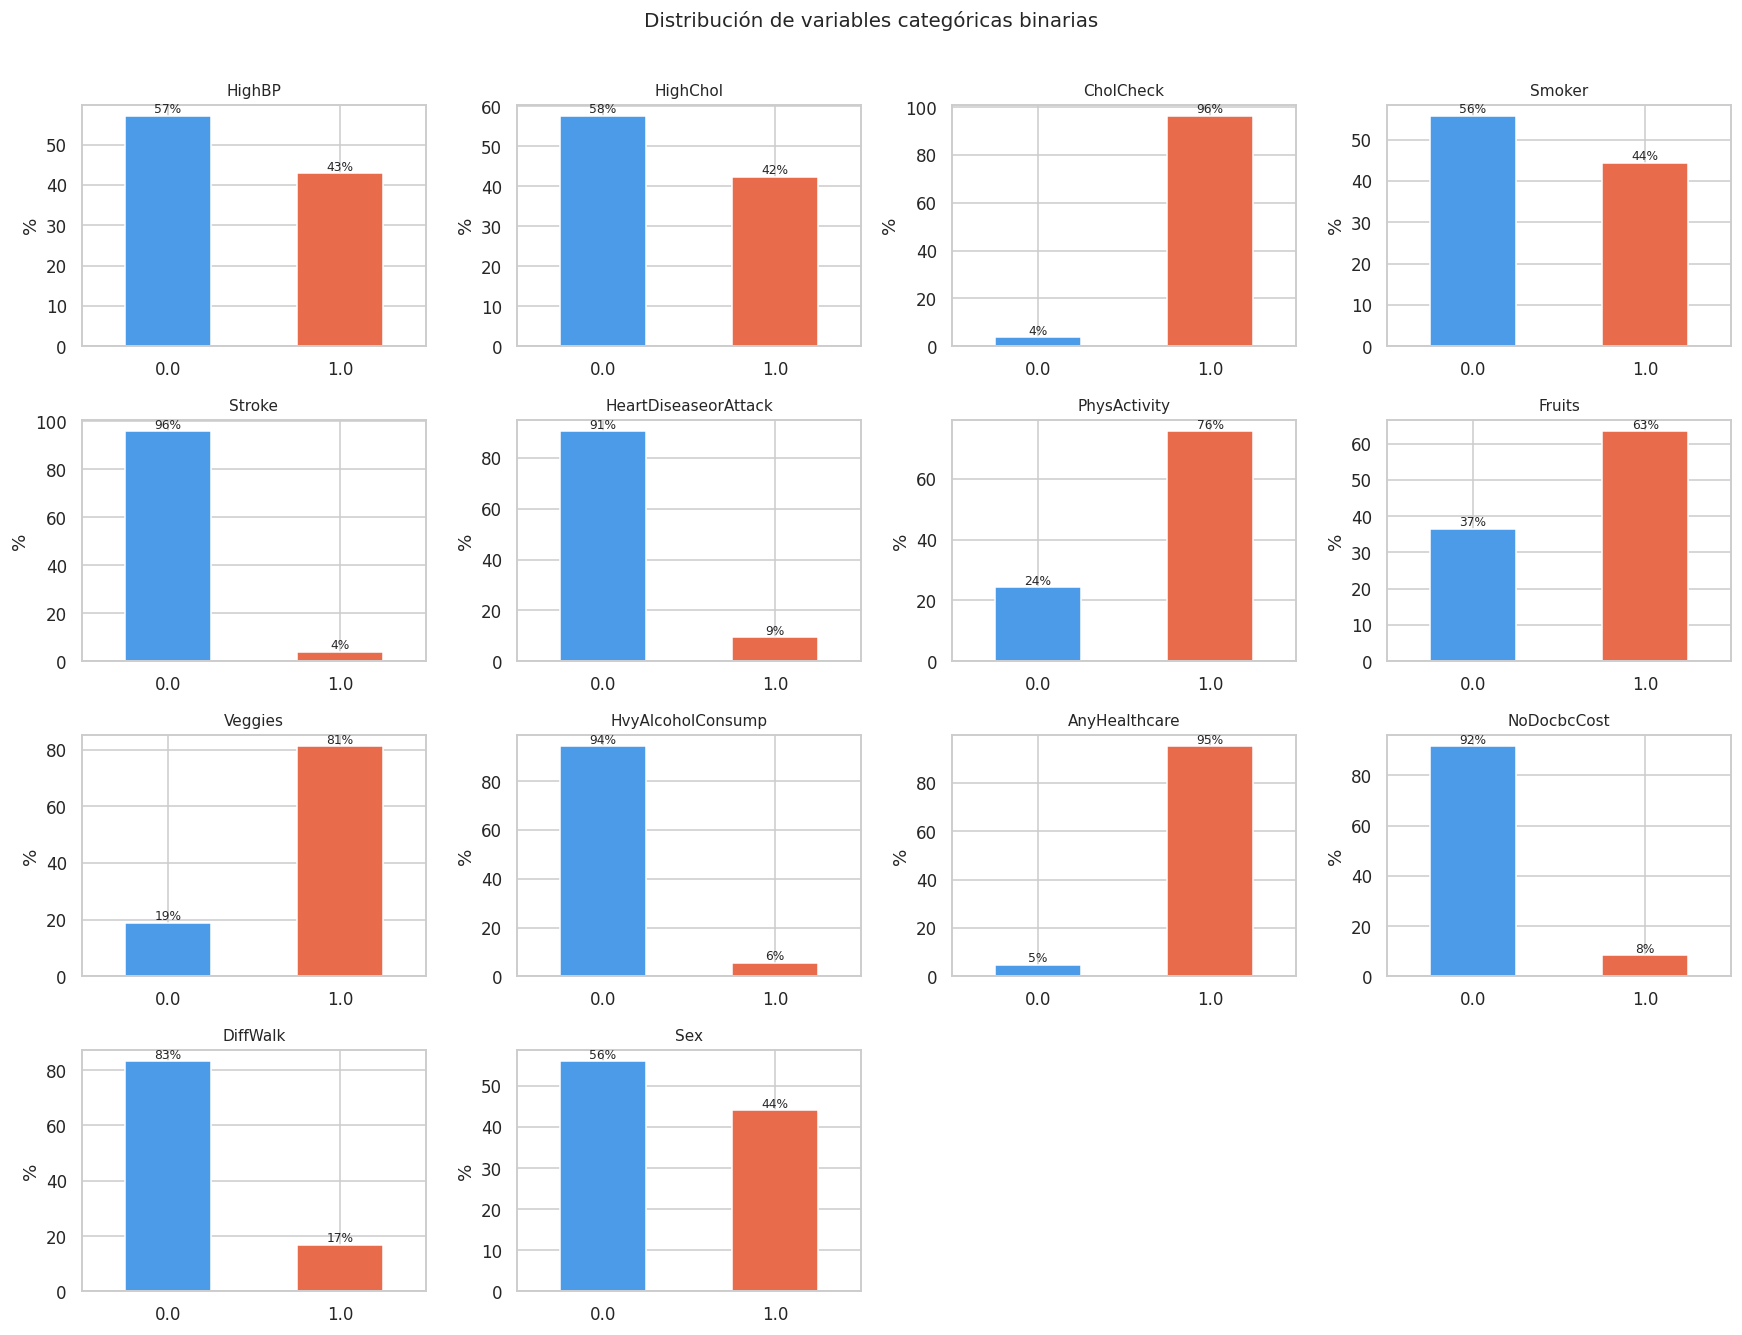

In [11]:
# Frecuencias de variables binarias nominales
bin_vars = [v for v in vars_nominales if v != 'Diabetes_binary']
n_cols = 4
n_rows = int(np.ceil(len(bin_vars) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, var in enumerate(bin_vars):
    ax = axes[i]
    pct = df[var].value_counts(normalize=True) * 100
    pct.sort_index().plot.bar(ax=ax, color=['#4C9BE8','#E86B4C'], edgecolor='white')
    ax.set_title(var, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.0f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de variables categóricas binarias', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_categoricas_binarias.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 4. Identificación de valores faltantes

In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

print('Valores faltantes por columna:')
missing_df = pd.DataFrame({'faltantes': missing, 'porcentaje (%)': missing_pct})
print(missing_df[missing_df['faltantes'] > 0].to_string() if missing.sum() > 0
      else '\n✓ El dataset no tiene valores faltantes en ninguna columna.')
print(f'\nTotal de valores nulos: {missing.sum()}')

Valores faltantes por columna:

✓ El dataset no tiene valores faltantes en ninguna columna.

Total de valores nulos: 0


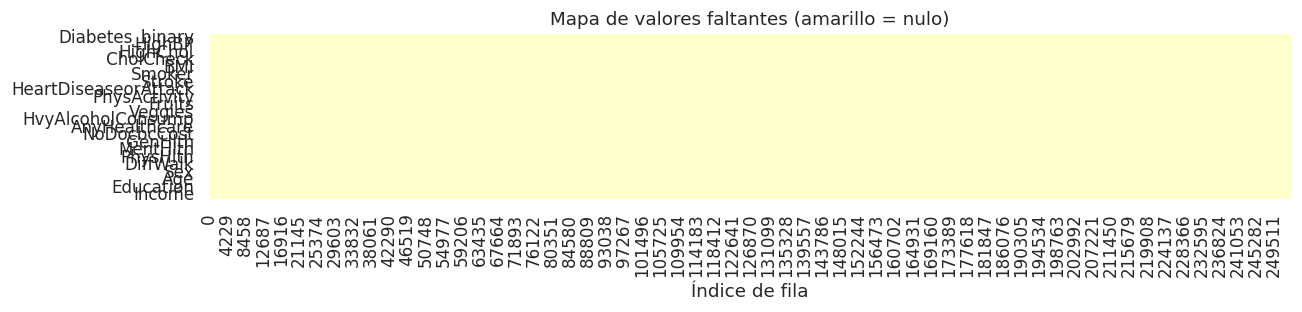

In [13]:
# Mapa visual de valores nulos (útil si hubiera faltantes)
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(df.isnull().T, cbar=False, cmap='YlOrRd', ax=ax, yticklabels=True)
ax.set_title('Mapa de valores faltantes (amarillo = nulo)', fontsize=12)
ax.set_xlabel('Índice de fila')
plt.tight_layout()
plt.show()

---
## 5. Identificación de valores atípicos

In [14]:
# Método IQR para las variables numéricas
def detectar_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = series[(series < lower) | (series > upper)]
    return {
        'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
        'límite_inferior': round(lower,2), 'límite_superior': round(upper,2),
        'n_outliers': len(outliers),
        'pct_outliers': round(len(outliers)/len(series)*100, 2)
    }

num_vars_analisis = vars_continuas + vars_discretas
outlier_report = pd.DataFrame(
    {var: detectar_outliers_iqr(df[var]) for var in num_vars_analisis}
).T
print('Detección de outliers por método IQR:')
outlier_report

Detección de outliers por método IQR:


,Q1,Q3,IQR,límite_inferior,límite_superior,n_outliers,pct_outliers
BMI,24.0,31.0,7.0,13.5,41.5,9847.0,3.88
MentHlth,0.0,2.0,2.0,-3.0,5.0,36208.0,14.27
PhysHlth,0.0,3.0,3.0,-4.5,7.5,40949.0,16.14


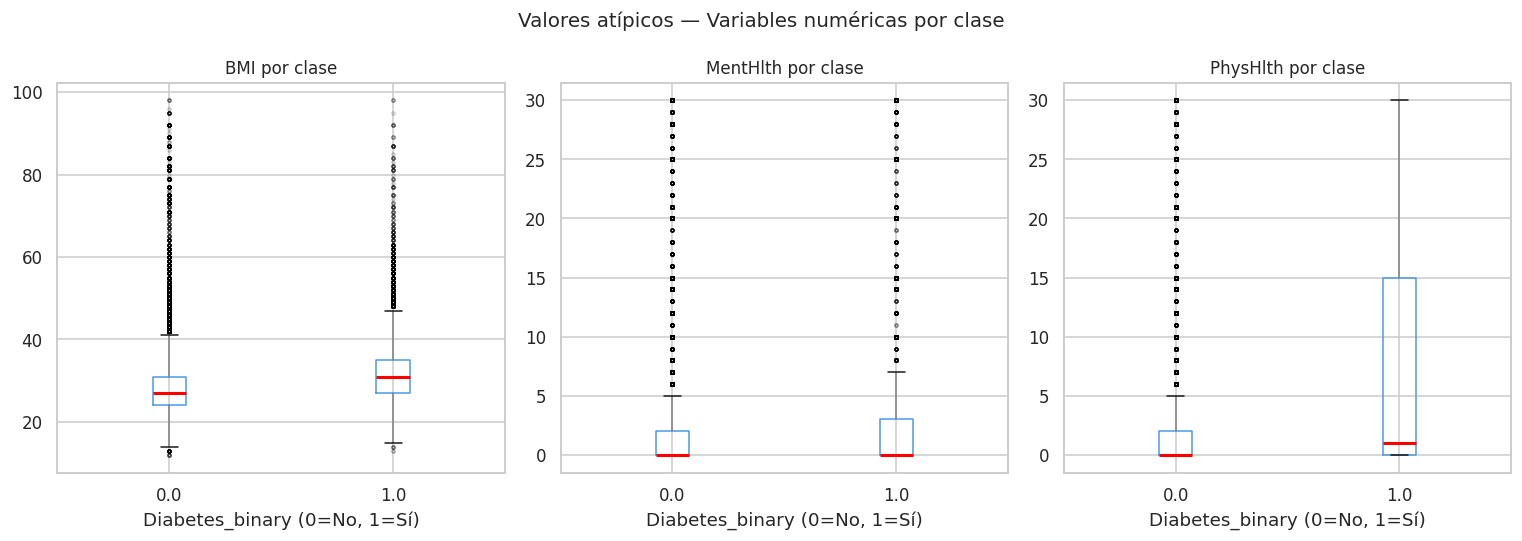

In [15]:
# Boxplots de variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, var in zip(axes, num_vars_analisis + vars_ordinales[:1]):
    df.boxplot(column=var, by='Diabetes_binary', ax=ax,
               boxprops=dict(color='#4C9BE8'),
               whiskerprops=dict(color='gray'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', alpha=0.2, markersize=2))
    ax.set_title(f'{var} por clase', fontsize=11)
    ax.set_xlabel('Diabetes_binary (0=No, 1=Sí)')

plt.suptitle('Valores atípicos — Variables numéricas por clase', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/fig_outliers_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()

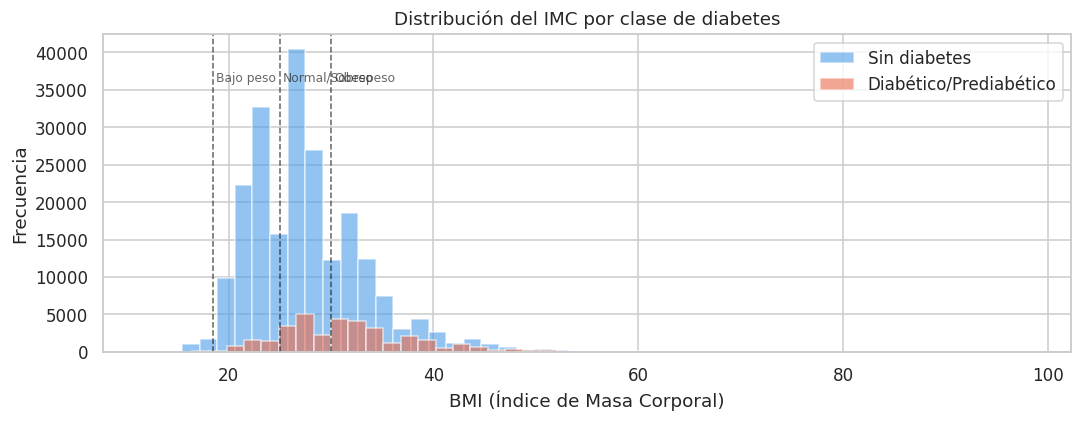

In [16]:
# Distribución del BMI con líneas de referencia clínicas
fig, ax = plt.subplots(figsize=(10, 4))
df[df['Diabetes_binary']==0]['BMI'].plot.hist(ax=ax, bins=50, alpha=0.6,
                                               color='#4C9BE8', label='Sin diabetes')
df[df['Diabetes_binary']==1]['BMI'].plot.hist(ax=ax, bins=50, alpha=0.6,
                                               color='#E86B4C', label='Diabético/Prediabético')
for val, lbl in [(18.5,'Bajo peso'), (25,'Normal/Sobrepeso'), (30,'Obeso')]:
    ax.axvline(val, color='black', linestyle='--', linewidth=1, alpha=0.6)
    ax.text(val+0.3, ax.get_ylim()[1]*0.85, lbl, fontsize=8, alpha=0.7)
ax.set_title('Distribución del IMC por clase de diabetes', fontsize=12)
ax.set_xlabel('BMI (Índice de Masa Corporal)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_bmi_por_clase.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 6. Análisis de correlación

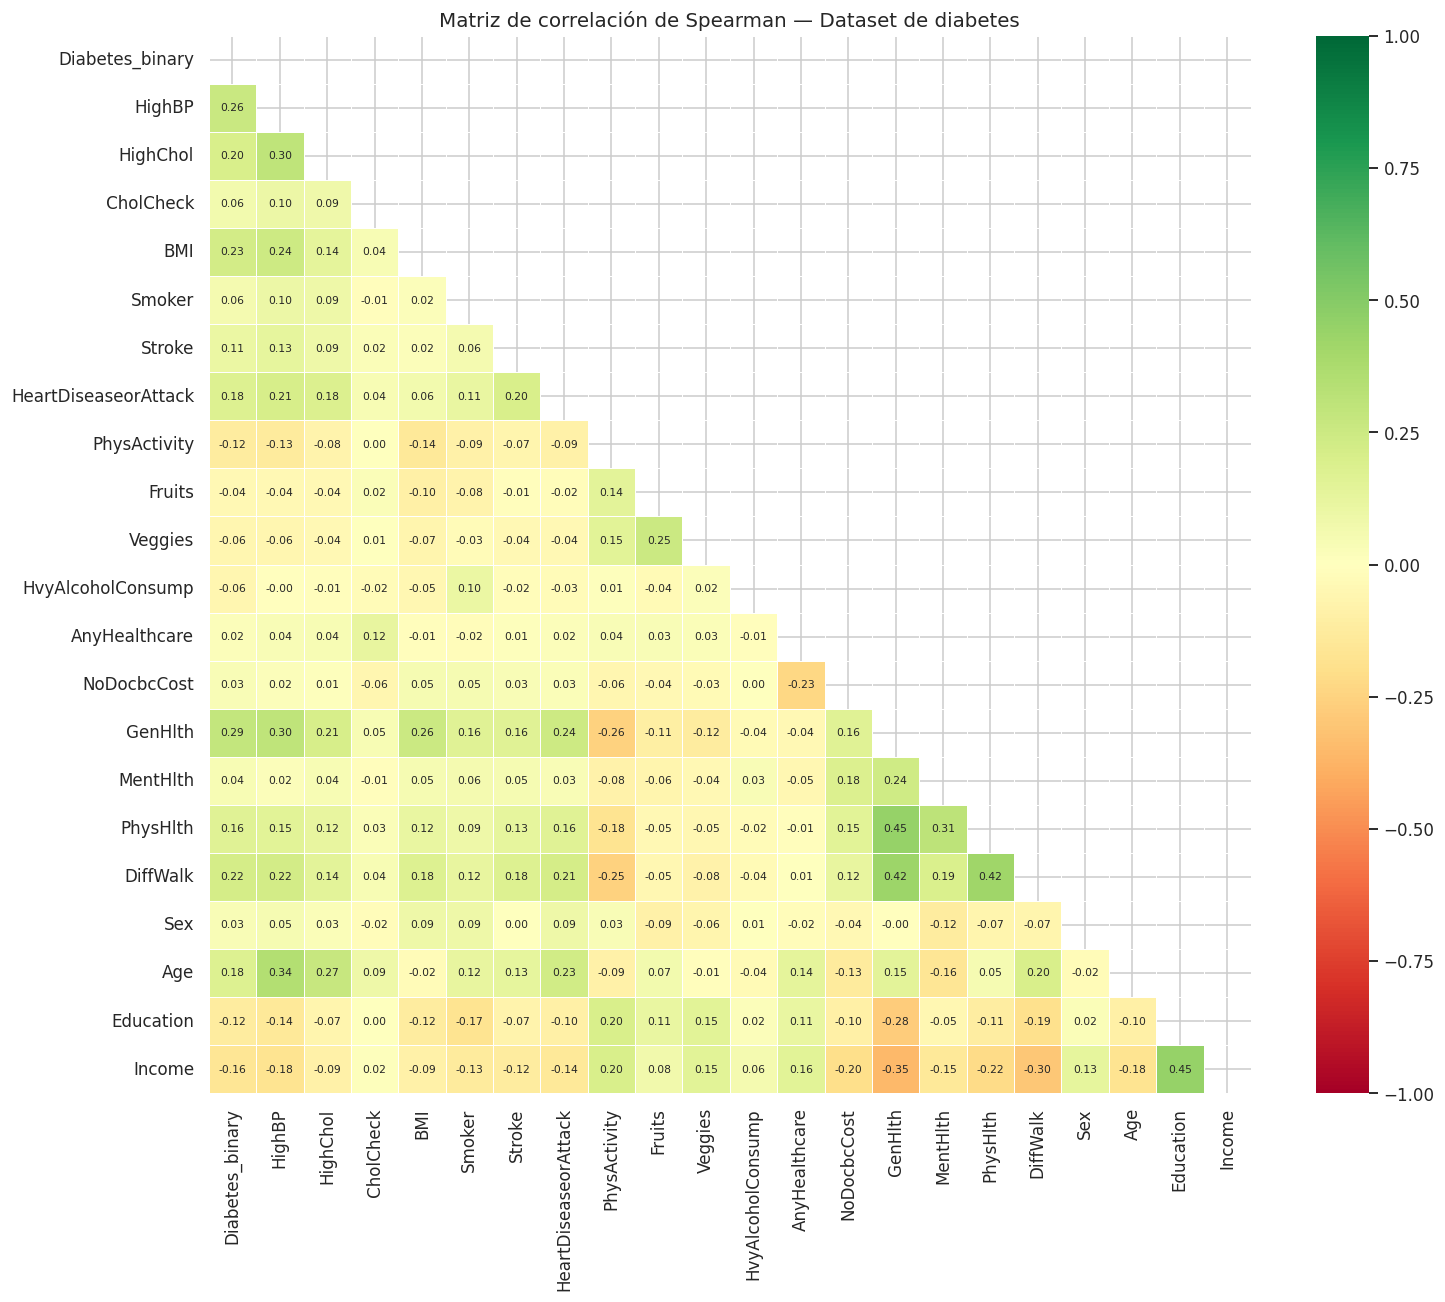

In [17]:
# Correlación de Spearman (adecuada para variables ordinales y no normales)
corr_spearman = df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(
    corr_spearman, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 7}, ax=ax
)
ax.set_title('Matriz de correlación de Spearman — Dataset de diabetes', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/fig_correlacion_spearman.png', dpi=110, bbox_inches='tight')
plt.show()

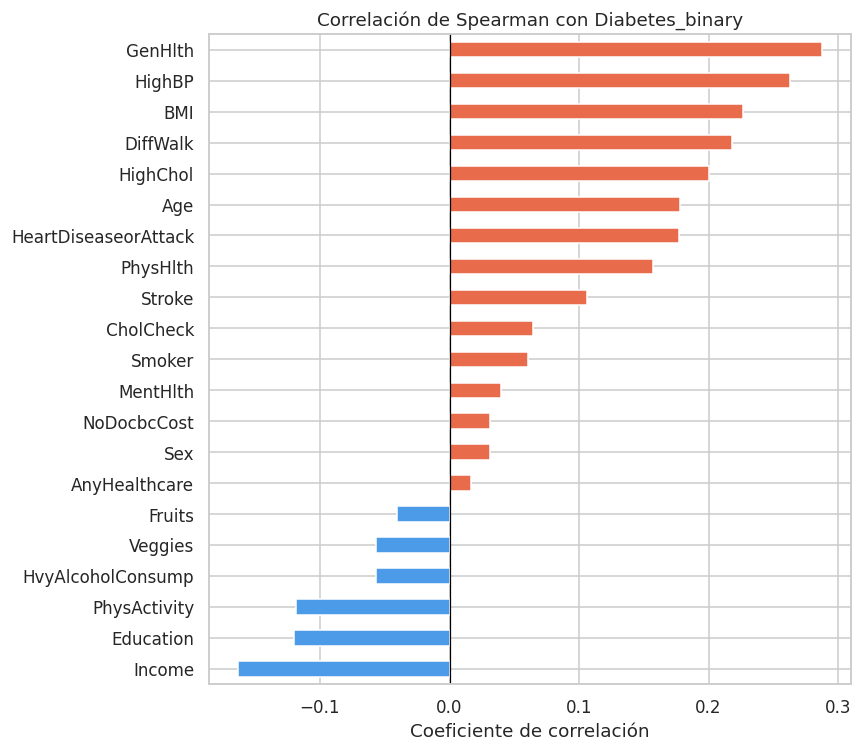


Top 5 variables más correlacionadas con diabetes:
GenHlth     0.287697
HighBP      0.263129
BMI         0.226314
DiffWalk    0.218344
HighChol    0.200276


In [18]:
# Correlación de cada variable con la variable objetivo (ordenada)
target_corr = corr_spearman['Diabetes_binary'].drop('Diabetes_binary').sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#E86B4C' if v > 0 else '#4C9BE8' for v in target_corr.values]
target_corr.plot.barh(ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Spearman con Diabetes_binary', fontsize=12)
ax.set_xlabel('Coeficiente de correlación')
plt.tight_layout()
plt.savefig('../reports/fig_correlacion_target.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nTop 5 variables más correlacionadas con diabetes:')
print(target_corr.abs().sort_values(ascending=False).head(5).to_string())

---
## 7. Análisis de relaciones entre variables (Boxplots)

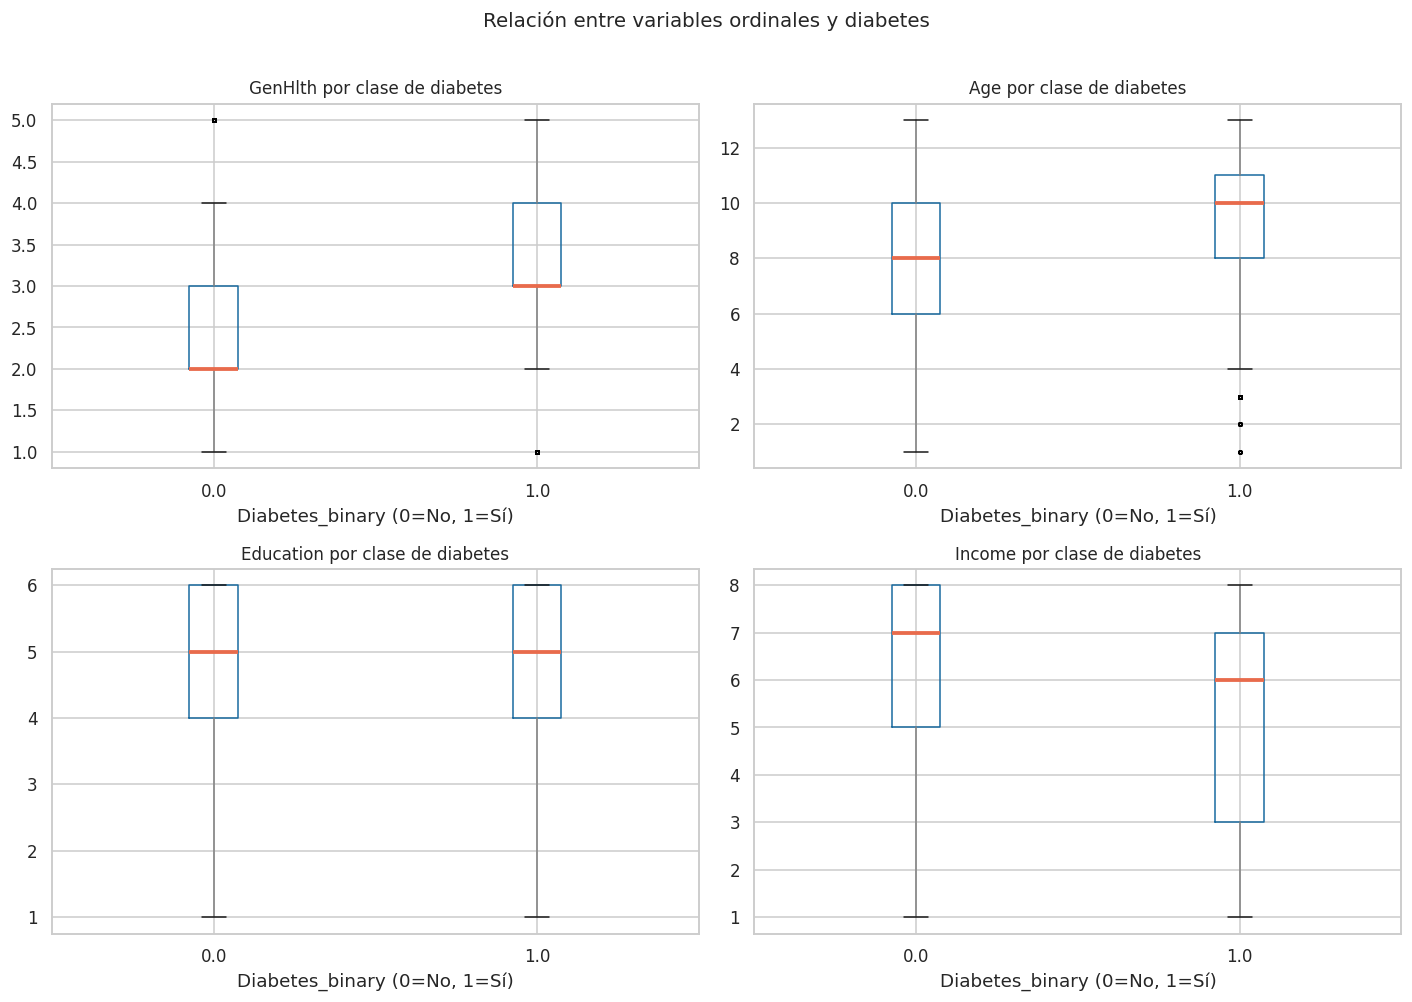

In [19]:
# Boxplots: variables ordinales vs Diabetes_binary
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, var in enumerate(vars_ordinales):
    ax = axes[i]
    df.boxplot(column=var, by='Diabetes_binary', ax=ax,
               boxprops=dict(color='#1a6ba0'),
               whiskerprops=dict(color='gray'),
               medianprops=dict(color='#E86B4C', linewidth=2.5),
               flierprops=dict(marker='o', alpha=0.1, markersize=2))
    ax.set_title(f'{var} por clase de diabetes', fontsize=11)
    ax.set_xlabel('Diabetes_binary (0=No, 1=Sí)')

plt.suptitle('Relación entre variables ordinales y diabetes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_boxplots_ordinales.png', dpi=110, bbox_inches='tight')
plt.show()

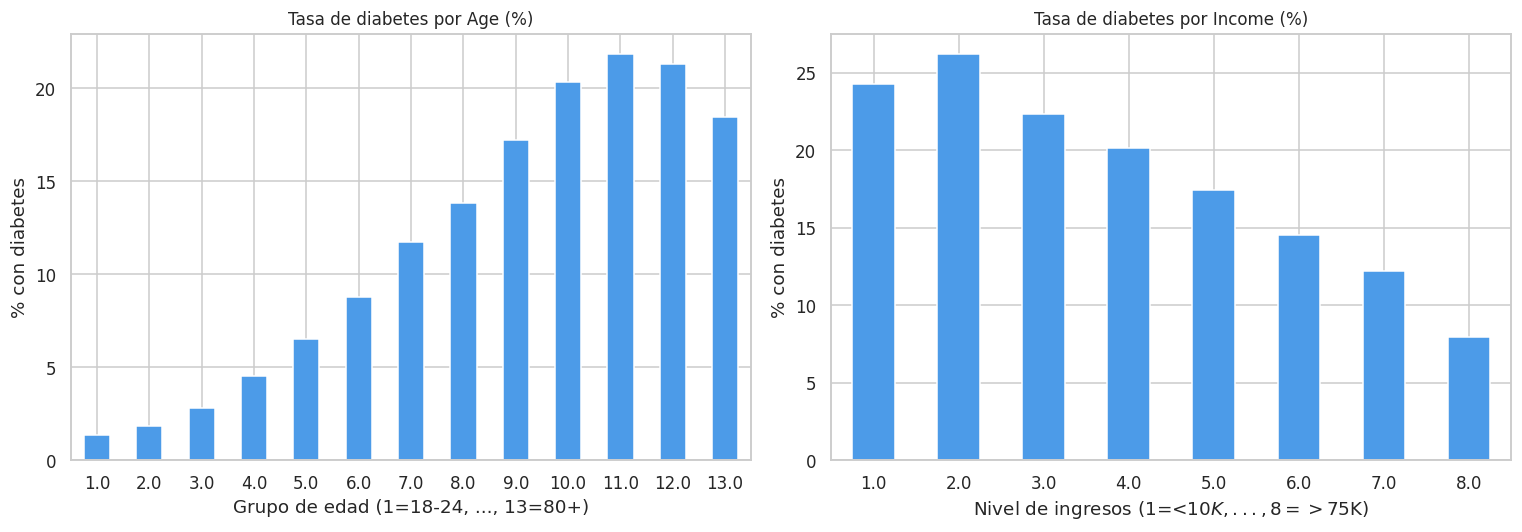

In [20]:
# Tasas de diabetes por grupo de edad e ingresos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var, xlabel in zip(
    axes,
    ['Age', 'Income'],
    ['Grupo de edad (1=18-24, ..., 13=80+)', 'Nivel de ingresos (1=<$10K, ..., 8=>$75K)']
):
    tasa = df.groupby(var)['Diabetes_binary'].mean() * 100
    tasa.plot.bar(ax=ax, color='#4C9BE8', edgecolor='white')
    ax.set_title(f'Tasa de diabetes por {var} (%)', fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('% con diabetes')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/fig_tasa_por_edad_ingresos.png', dpi=110, bbox_inches='tight')
plt.show()

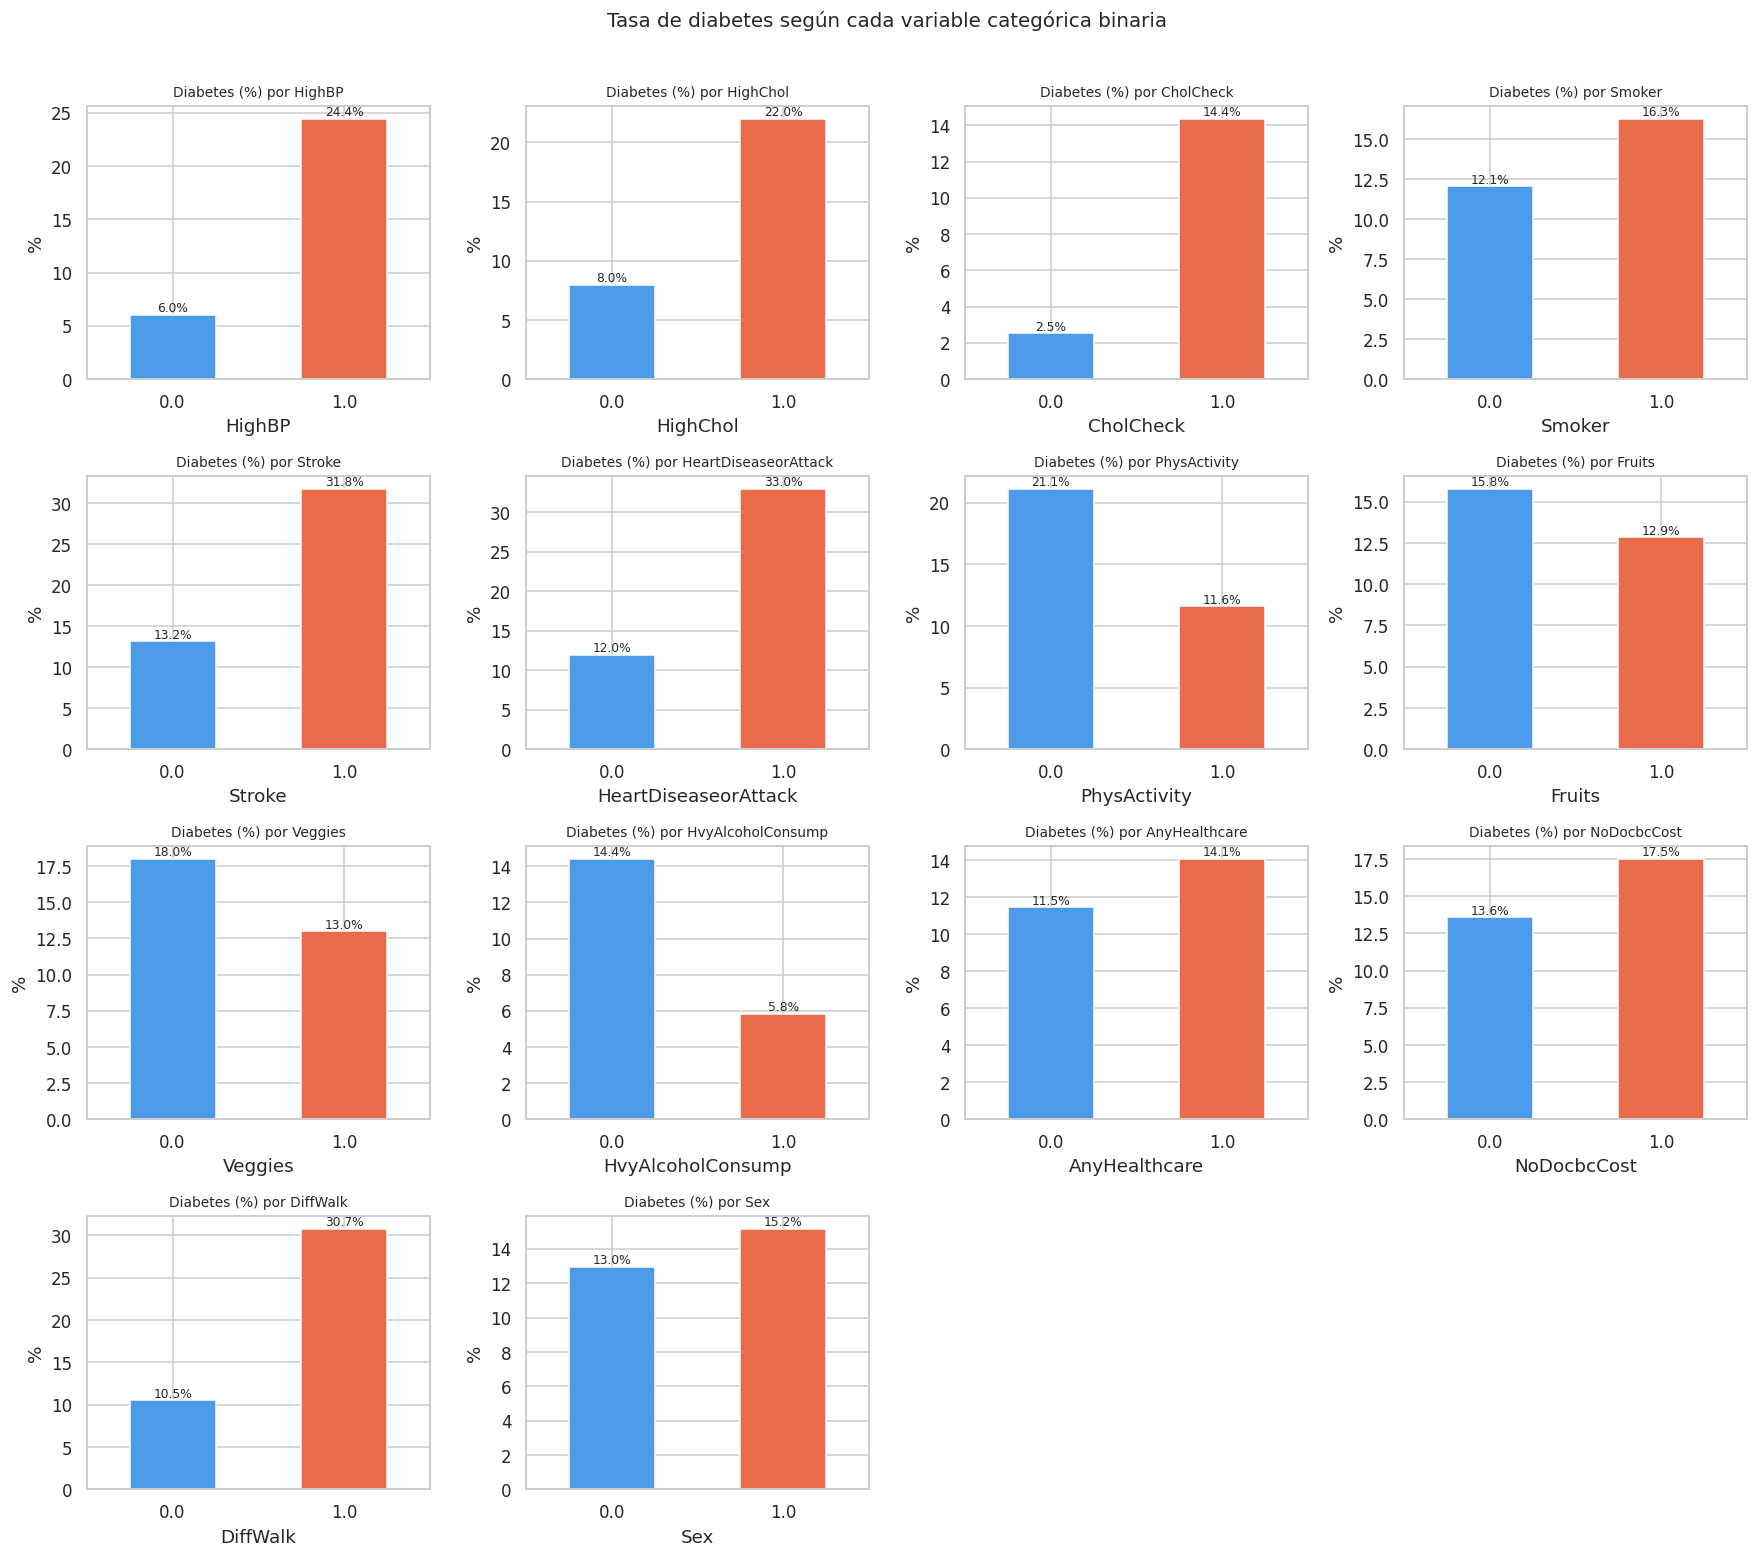

In [21]:
# Tasas de diabetes para todas las variables binarias
n_cols = 4
n_rows = int(np.ceil(len(bin_vars) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, var in enumerate(bin_vars):
    ax = axes[i]
    tasa = df.groupby(var)['Diabetes_binary'].mean() * 100
    tasa.plot.bar(ax=ax, color=['#4C9BE8', '#E86B4C'], edgecolor='white')
    ax.set_title(f'Diabetes (%) por {var}', fontsize=9)
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Tasa de diabetes según cada variable categórica binaria', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_tasa_por_binarias.png', dpi=110, bbox_inches='tight')
plt.show()

---
## 8. Pruebas de asociación y dependencia

In [22]:
# ── Prueba Chi-cuadrado para variables categóricas nominales ─────────────────
print('Chi-cuadrado — Variables nominales vs Diabetes_binary')
print('='*70)

chi2_results = []
for var in bin_vars:
    tabla = pd.crosstab(df[var], df['Diabetes_binary'])
    chi2, p, dof, _ = chi2_contingency(tabla)
    # V de Cramér (tamaño del efecto)
    n = tabla.sum().sum()
    cramer_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    chi2_results.append({
        'variable': var, 'chi2': round(chi2, 2),
        'p_value': round(p, 6), 'gl': dof,
        'cramer_v': round(cramer_v, 4),
        'significativa': '✓' if p < 0.05 else '✗'
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('cramer_v', ascending=False)
print(chi2_df.to_string(index=False))

Chi-cuadrado — Variables nominales vs Diabetes_binary
            variable     chi2  p_value  gl  cramer_v significativa
              HighBP 17562.45      0.0   1    0.2631             ✓
            DiffWalk 12092.32      0.0   1    0.2183             ✓
            HighChol 10174.07      0.0   1    0.2003             ✓
HeartDiseaseorAttack  7971.16      0.0   1    0.1773             ✓
        PhysActivity  3539.42      0.0   1    0.1181             ✓
              Stroke  2838.92      0.0   1    0.1058             ✓
           CholCheck  1062.94      0.0   1    0.0647             ✓
              Smoker   937.06      0.0   1    0.0608             ✓
   HvyAlcoholConsump   825.12      0.0   1    0.0570             ✓
             Veggies   811.81      0.0   1    0.0566             ✓
              Fruits   421.61      0.0   1    0.0408             ✓
         NoDocbcCost   250.31      0.0   1    0.0314             ✓
                 Sex   250.41      0.0   1    0.0314             ✓
       A

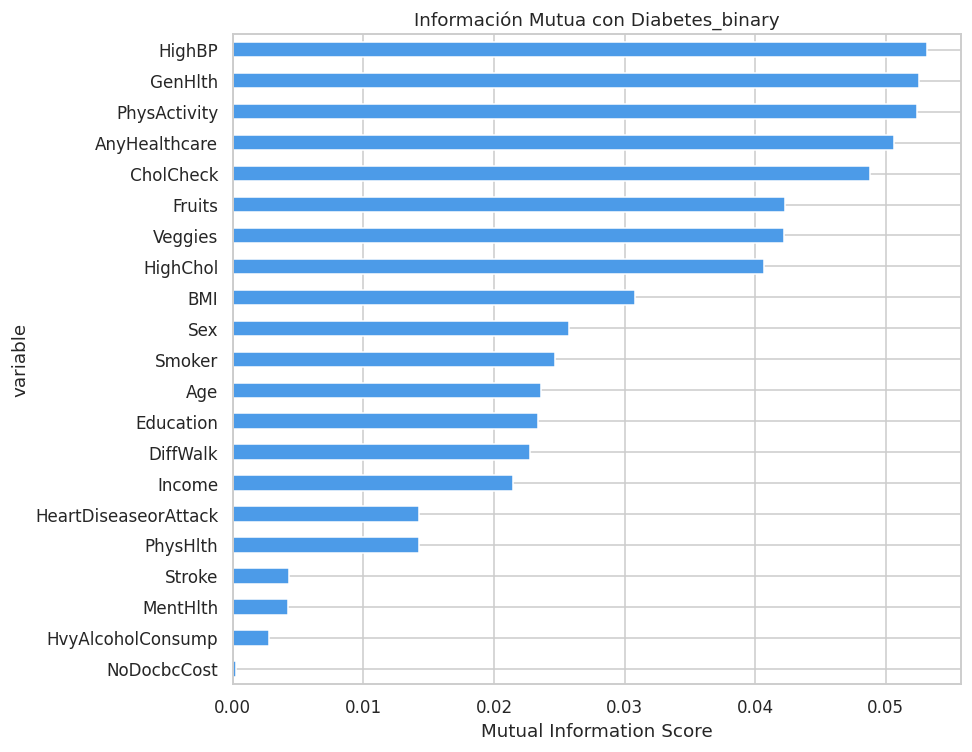


Top 8 variables con mayor información mutua:
     variable  mutual_info
       HighBP     0.053140
      GenHlth     0.052544
 PhysActivity     0.052416
AnyHealthcare     0.050609
    CholCheck     0.048799
       Fruits     0.042253
      Veggies     0.042183
     HighChol     0.040654


In [23]:
# ── Información Mutua para todas las variables ────────────────────────────────
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'variable': X.columns, 'mutual_info': mi_scores})
mi_df = mi_df.sort_values('mutual_info', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
mi_df.set_index('variable')['mutual_info'].sort_values().plot.barh(
    ax=ax, color='#4C9BE8', edgecolor='white'
)
ax.set_title('Información Mutua con Diabetes_binary', fontsize=12)
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.savefig('../reports/fig_mutual_info.png', dpi=110, bbox_inches='tight')
plt.show()

print('\nTop 8 variables con mayor información mutua:')
print(mi_df.head(8).to_string(index=False))

In [24]:
# ── Kruskal-Wallis para variables numéricas vs clase ──────────────────────────
print('Prueba Kruskal-Wallis — Variables numéricas vs Diabetes_binary')
print('='*60)

for var in num_vars_analisis + vars_ordinales:
    grupo0 = df[df['Diabetes_binary']==0][var]
    grupo1 = df[df['Diabetes_binary']==1][var]
    stat, p = kruskal(grupo0, grupo1)
    sig = '✓ Diferencia significativa' if p < 0.05 else '✗ Sin diferencia significativa'
    print(f'  {var:<25} H={stat:>10.2f}   p={p:.2e}   {sig}')

Prueba Kruskal-Wallis — Variables numéricas vs Diabetes_binary
  BMI                       H=  12992.96   p=0.00e+00   ✓ Diferencia significativa
  MentHlth                  H=    406.88   p=1.75e-90   ✓ Diferencia significativa
  PhysHlth                  H=   6233.17   p=0.00e+00   ✓ Diferencia significativa
  GenHlth                   H=  20996.94   p=0.00e+00   ✓ Diferencia significativa
  Age                       H=   8009.08   p=0.00e+00   ✓ Diferencia significativa
  Education                 H=   3655.28   p=0.00e+00   ✓ Diferencia significativa
  Income                    H=   6765.22   p=0.00e+00   ✓ Diferencia significativa


---
## 9. Tratamiento de datos faltantes e imputación

In [25]:
# El dataset BRFSS no tiene valores nulos reales.
# Para cumplir el requisito del laboratorio, se introduce un 5% de nulos
# artificiales en las variables numéricas/ordinales y se comparan dos métodos.

np.random.seed(42)
vars_imputar = ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age']
df_missing = df.copy()

MISSING_RATE = 0.05
for var in vars_imputar:
    idx = np.random.choice(df_missing.index, size=int(len(df_missing)*MISSING_RATE), replace=False)
    df_missing.loc[idx, var] = np.nan

print(f'Valores nulos introducidos ({MISSING_RATE*100:.0f}% por variable):')
print(df_missing[vars_imputar].isnull().sum().to_string())

Valores nulos introducidos (5% por variable):
BMI         12684
MentHlth    12684
PhysHlth    12684
GenHlth     12684
Age         12684


In [26]:
# ── Método 1: Mediana (medida de tendencia central) ──────────────────────────
imputer_mediana = SimpleImputer(strategy='median')
df_mediana = df_missing.copy()
df_mediana[vars_imputar] = imputer_mediana.fit_transform(df_missing[vars_imputar])

print('Método 1 — Imputación por mediana:')
print(f'  Nulos restantes: {df_mediana[vars_imputar].isnull().sum().sum()}')
print(df_mediana[vars_imputar].describe().round(2))

Método 1 — Imputación por mediana:
  Nulos restantes: 0
             BMI   MentHlth   PhysHlth    GenHlth        Age
count  253680.00  253680.00  253680.00  253680.00  253680.00
mean       28.31       3.02       4.03       2.49       8.03
std         6.46       7.26       8.54       1.05       2.98
min        12.00       0.00       0.00       1.00       1.00
25%        24.00       0.00       0.00       2.00       6.00
50%        27.00       0.00       0.00       2.00       8.00
75%        31.00       2.00       3.00       3.00      10.00
max        98.00      30.00      30.00       5.00      13.00


In [27]:
# ── Método 2: KNN Imputer (k=5) ───────────────────────────────────────────────
imputer_knn = KNNImputer(n_neighbors=5)
df_knn = df_missing.copy()
df_knn[vars_imputar] = imputer_knn.fit_transform(df_missing[vars_imputar])

print('Método 2 — Imputación por KNN (k=5):')
print(f'  Nulos restantes: {df_knn[vars_imputar].isnull().sum().sum()}')
print(df_knn[vars_imputar].describe().round(2))

Método 2 — Imputación por KNN (k=5):
  Nulos restantes: 0
             BMI   MentHlth   PhysHlth    GenHlth        Age
count  253680.00  253680.00  253680.00  253680.00  253680.00
mean       28.38       3.17       4.21       2.51       8.04
std         6.49       7.28       8.57       1.05       3.00
min        12.00       0.00       0.00       1.00       1.00
25%        24.00       0.00       0.00       2.00       6.00
50%        27.00       0.00       0.00       2.00       8.00
75%        31.00       2.00       3.00       3.00      10.00
max        98.00      30.00      30.00       5.00      13.00


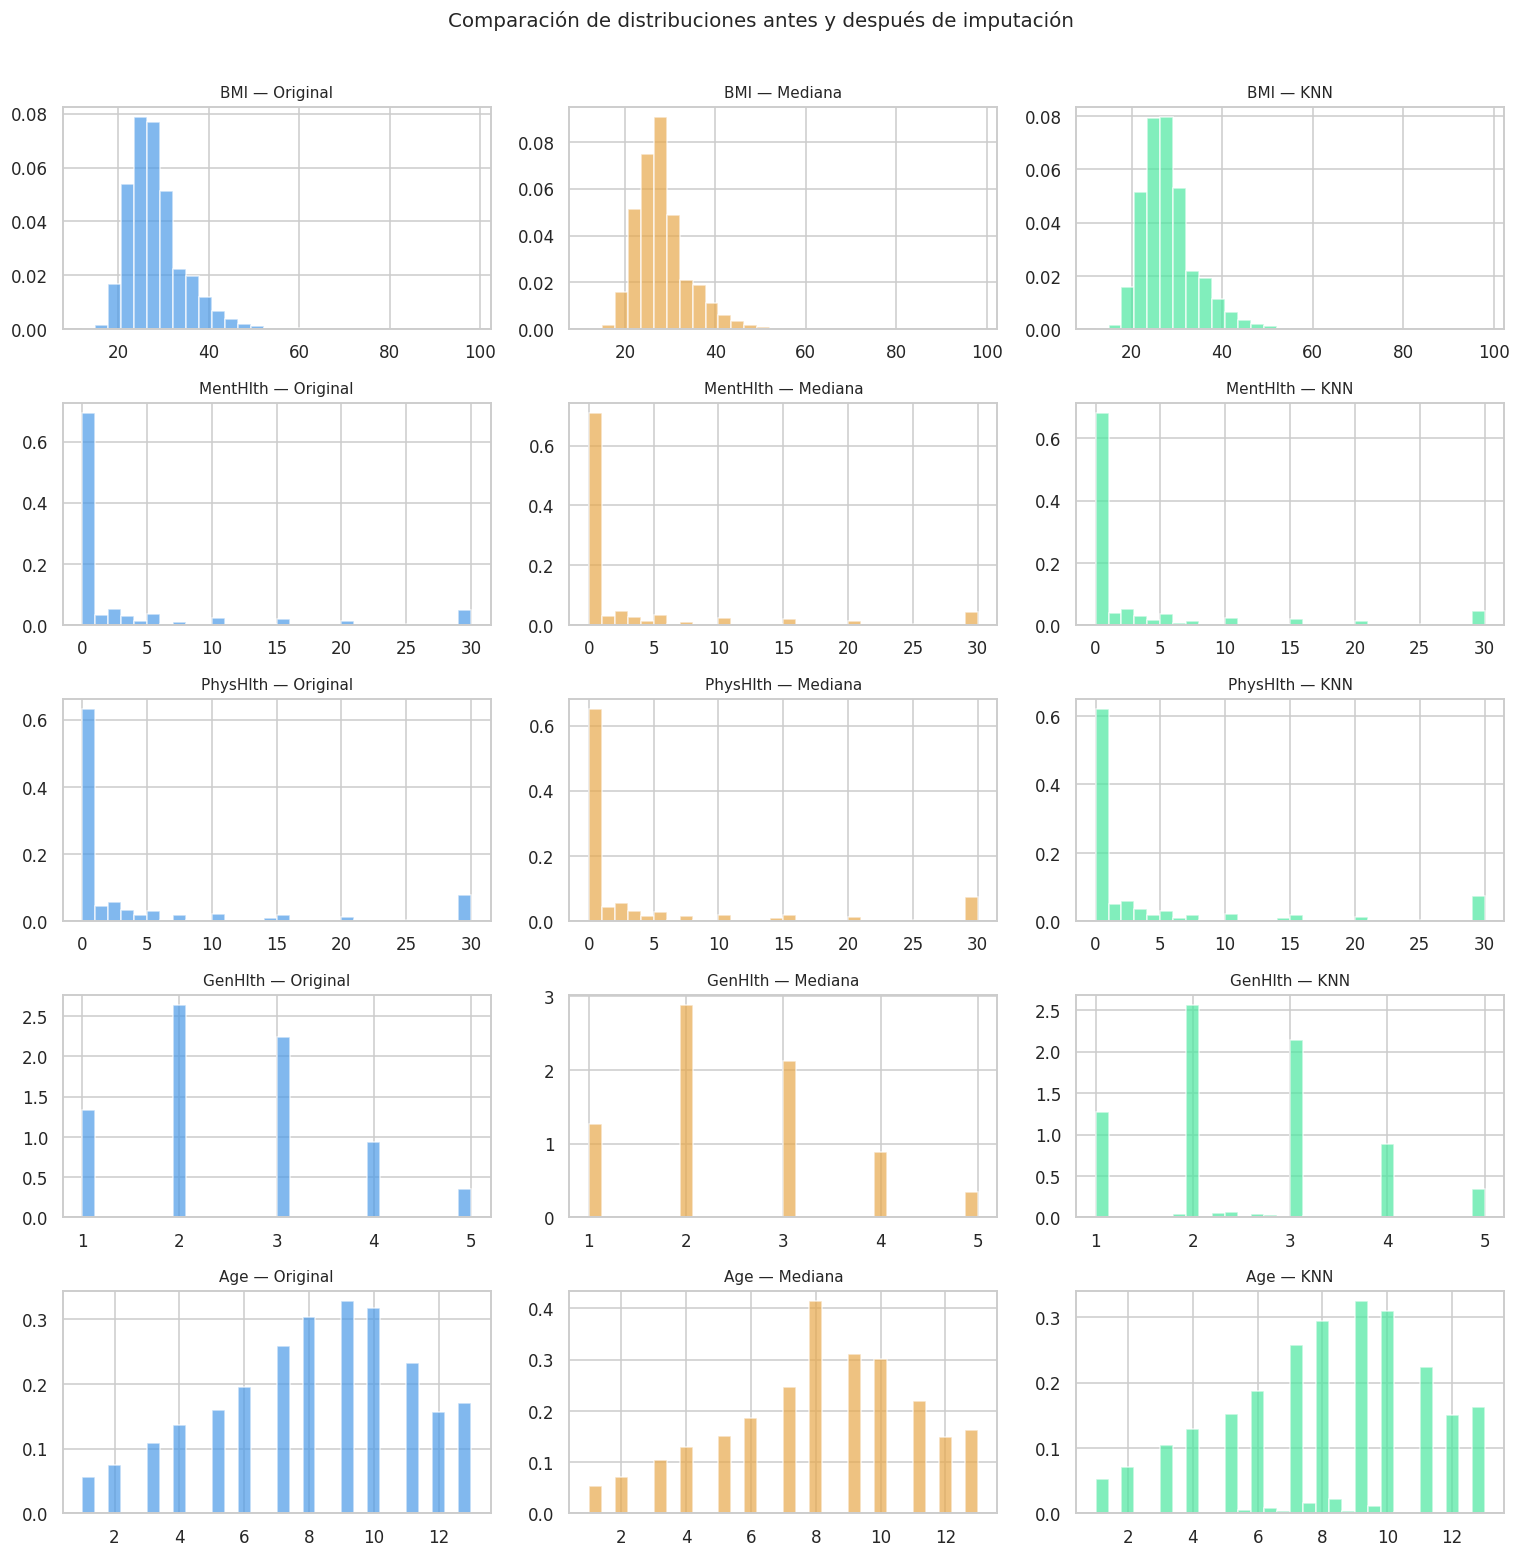

In [28]:
# ── Comparación visual de los dos métodos ────────────────────────────────────
fig, axes = plt.subplots(len(vars_imputar), 3, figsize=(14, len(vars_imputar)*2.8))

for i, var in enumerate(vars_imputar):
    bins = 30
    kw = dict(bins=bins, alpha=0.7, edgecolor='white', density=True)

    axes[i, 0].hist(df[var], color='#4C9BE8', **kw)
    axes[i, 0].set_title(f'{var} — Original', fontsize=10)

    axes[i, 1].hist(df_mediana[var], color='#E8A84C', **kw)
    axes[i, 1].set_title(f'{var} — Mediana', fontsize=10)

    axes[i, 2].hist(df_knn[var], color='#4CE8A0', **kw)
    axes[i, 2].set_title(f'{var} — KNN', fontsize=10)

fig.suptitle('Comparación de distribuciones antes y después de imputación', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_comparacion_imputacion.png', dpi=110, bbox_inches='tight')
plt.show()

In [29]:
# ── Tabla comparativa de estadísticos post-imputación ────────────────────────
rows = []
for var in vars_imputar:
    for metodo, data in [('Original', df), ('Mediana', df_mediana), ('KNN', df_knn)]:
        rows.append({
            'variable': var, 'metodo': metodo,
            'media': round(data[var].mean(), 3),
            'mediana': round(data[var].median(), 3),
            'std': round(data[var].std(), 3)
        })

comp_df = pd.DataFrame(rows)
print('Comparativa de estadísticos antes y después de la imputación:')
comp_df.pivot(index=['variable','metodo'], columns=[], values=['media','mediana','std'])
print(comp_df.to_string(index=False))

Comparativa de estadísticos antes y después de la imputación:
variable   metodo  media  mediana   std
     BMI Original 28.382     27.0 6.609
     BMI  Mediana 28.309     27.0 6.455
     BMI      KNN 28.379     27.0 6.493
MentHlth Original  3.185      0.0 7.413
MentHlth  Mediana  3.023      0.0 7.256
MentHlth      KNN  3.167      0.0 7.276
PhysHlth Original  4.242      0.0 8.718
PhysHlth  Mediana  4.028      0.0 8.545
PhysHlth      KNN  4.211      0.0 8.572
 GenHlth Original  2.511      2.0 1.068
 GenHlth  Mediana  2.486      2.0 1.047
 GenHlth      KNN  2.505      2.0 1.050
     Age Original  8.032      8.0 3.054
     Age  Mediana  8.031      8.0 2.977
     Age      KNN  8.042      8.0 2.996


### Justificación del método de imputación

| Criterio | Mediana | KNN |
|---|---|---|
| Preserva distribución | Parcialmente (introduce picos en la mediana) | Mejor: respeta la distribución local |
| Costo computacional | Muy bajo | Moderado (aumenta con el tamaño del dataset) |
| Sensible a outliers | No (usa mediana) | Sí (distancia euclidiana afectada) |
| Usa relaciones entre variables | No | Sí |

**Conclusión:** Para este dataset, dado que las variables como `BMI`, `Age` y `GenHlth` tienen relaciones conocidas entre sí (a mayor edad, mayor IMC promedio; a peor salud general, más días de mala salud física), la imputación por **KNN** es más adecuada porque aprovecha esas correlaciones para estimar valores más realistas. La imputación por mediana es aceptable como alternativa rápida cuando el porcentaje de nulos es bajo (<5%).

---
## 10. Conclusiones del EDA

In [30]:
print('='*65)
print('RESUMEN DE HALLAZGOS — EDA Dataset de Clasificación (Diabetes)')
print('='*65)

print(f"""
1. DESBALANCEO DE CLASES
   • {(df['Diabetes_binary']==0).mean()*100:.1f}% sin diabetes vs
     {(df['Diabetes_binary']==1).mean()*100:.1f}% con diabetes/prediabetes.
   • Implica que no se debe evaluar el modelo solo por exactitud.
   • Se recomienda usar AUC-ROC, F1 y métricas por clase.

2. VARIABLES MÁS RELEVANTES (según correlación y mutual info)
   • GenHlth, BMI, Age, HighBP y HighChol son los predictores
     con mayor asociación con la variable objetivo.
   • El IMC promedio de diabéticos ({df[df['Diabetes_binary']==1]['BMI'].mean():.1f})
     es notablemente mayor que el de no diabéticos ({df[df['Diabetes_binary']==0]['BMI'].mean():.1f}).

3. VALORES ATÍPICOS
   • BMI tiene outliers superiores (valores >50), pero representan
     casos clínicos reales (obesidad mórbida), no errores de datos.
   • MentHlth y PhysHlth tienen concentración de ceros (personas sanas)
     con cola larga hacia 30 días.

4. VALORES FALTANTES
   • El dataset original no tiene valores nulos.
   • En un escenario con nulos, KNN es preferible a la mediana
     porque aprovecha correlaciones entre variables.

5. PRUEBAS ESTADÍSTICAS
   • Todas las variables nominales presentaron asociación
     estadísticamente significativa con Diabetes_binary (p<0.05).
   • Las pruebas Kruskal-Wallis confirman diferencias significativas
     en todas las variables numéricas entre las dos clases.
""")

RESUMEN DE HALLAZGOS — EDA Dataset de Clasificación (Diabetes)

1. DESBALANCEO DE CLASES
   • 86.1% sin diabetes vs
     13.9% con diabetes/prediabetes.
   • Implica que no se debe evaluar el modelo solo por exactitud.
   • Se recomienda usar AUC-ROC, F1 y métricas por clase.

2. VARIABLES MÁS RELEVANTES (según correlación y mutual info)
   • GenHlth, BMI, Age, HighBP y HighChol son los predictores
     con mayor asociación con la variable objetivo.
   • El IMC promedio de diabéticos (31.9)
     es notablemente mayor que el de no diabéticos (27.8).

3. VALORES ATÍPICOS
   • BMI tiene outliers superiores (valores >50), pero representan
     casos clínicos reales (obesidad mórbida), no errores de datos.
   • MentHlth y PhysHlth tienen concentración de ceros (personas sanas)
     con cola larga hacia 30 días.

4. VALORES FALTANTES
   • El dataset original no tiene valores nulos.
   • En un escenario con nulos, KNN es preferible a la mediana
     porque aprovecha correlaciones entre variab